# Image Classification with Machine Learning

This project aims to build a machine learning model that recognizes handwritten digits from images.

Steps:

**1. Data Preparation** – loading, splitting, and visualizing the MNIST dataset

**2. Data Preprocessing** – scaling, reshaping, and transforming the data

**3. Classification Model** – building, training, and evaluating the model

**4. Hyperparameter Tuning** – experimenting with different settings to improve performance

**5. Visualization** – showing predictions and analyzing interesting cases

**6. Conclusion and Reflection** – summarizing findings and evaluating the model's effectiveness

In [ ]:
# Import necessary libraries
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import fetch_openml
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, precision_recall_curve, roc_curve, roc_auc_score
from sklearn.model_selection import cross_val_predict, StratifiedKFold, cross_val_score
from sklearn.base import clone, BaseEstimator
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.calibration import CalibratedClassifierCV
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import os

## **1. Data Preparation**

###Loading MNIST dataset
We load the MNIST dataset, which contains 70,000 images of handwritten digits (0–9). Each image is 28×28 pixels and is flattened into 784 features.

- X contains the image data (features).

- y contains the labels (the digit each image represents).

In [ ]:
# Load MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"]

print("Shape of X (features):", X.shape)
print("Shape of y (labels):", y.shape)

Shape of X (features): (70000, 784)
Shape of y (labels): (70000,)


Converting labels from string to integer

In [ ]:
# Convert labels from string to integer
y = y.astype(np.uint8)

###You split the dataset into training and test sets.
- First 60,000 samples → training set
- Last 10,000 samples → testing set

In [ ]:
# Split the dataset
X_train, X_test = X[:20000], X[60000:]
y_train, y_test = y[:20000], y[60000:]

In [ ]:
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (20000, 784)
Test set size: (10000, 784)


### Visualize the data
Displaying sample images helps verify the dataset and understand variations in handwritten digits.

In [ ]:
# ---------------------------------------------------------
# Visualize a few sample digits
# ---------------------------------------------------------
def plot_digit(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap=mpl.cm.binary, interpolation="nearest")
    plt.axis("off")

Displaying first example:

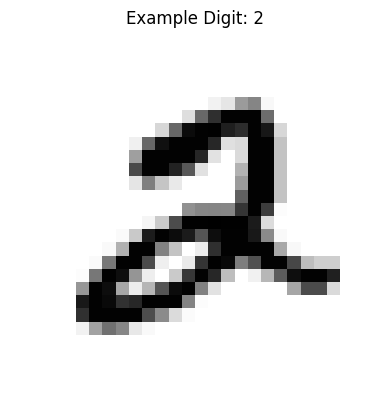

In [ ]:
some_digit = X[5]
plot_digit(some_digit)
plt.title(f"Example Digit: {y[5]}")
plt.show()

Displaying example 2:

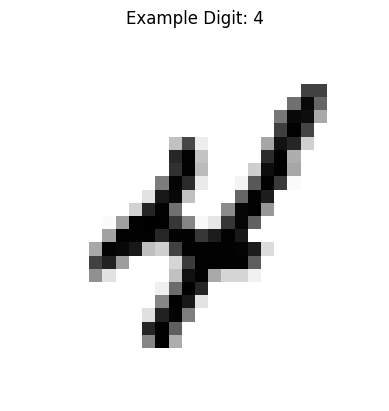

In [ ]:
some_digit = X[9]
plot_digit(some_digit)
plt.title(f"Example Digit: {y[9]}")
plt.show()

Displaying all the 100 numbers:

In [ ]:
# Function to plot digits in a grid
def plot_digits(instances, images_per_row=10, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    n_rows = (len(instances) - 1) // images_per_row + 1

    n_empty = n_rows * images_per_row - len(instances)
    padded_instances = np.concatenate([instances, np.zeros((n_empty, size * size))], axis=0)

    image_grid = padded_instances.reshape((n_rows, images_per_row, size, size))
    big_image = image_grid.transpose(0, 2, 1, 3).reshape(n_rows * size,
                                                         images_per_row * size)
    plt.imshow(big_image, cmap=mpl.cm.binary, **options)
    plt.axis("off")

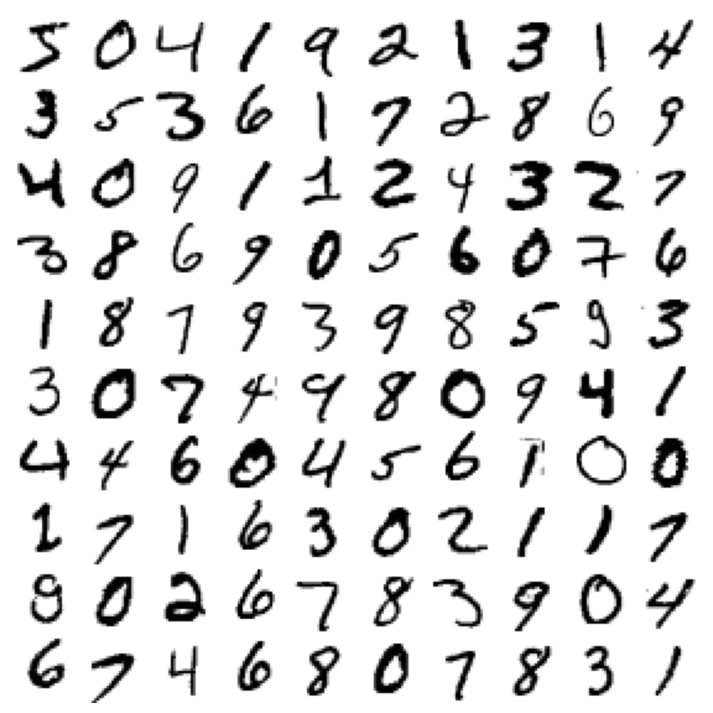

In [ ]:
# Display the first 100 digits
plt.figure(figsize=(9, 9))
example_images = X[:100]  # assuming X contains your MNIST data
plot_digits(example_images, images_per_row=10)
plt.show()

## **2. Data Preprocessing**
Before training any model, we need to prepare the data so that it can be properly used by machine learning algorithms. This step includes converting labels, normalizing features, and splitting the dataset for training and testing.

### Convert labels from strings to integers
- Original labels are strings (“0” to “9”).
- ML models require numeric labels for computations.
- astype(np.uint8) converts labels to integers so that the model can classify them.

In [ ]:
y = y.astype(np.uint8)

### Scale features
- Pixel values range from 0 to 255, which can cause models like SVM or SGD to converge slowly.
- Normalizing the data to have mean 0 and standard deviation 1 improves training performance.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.astype(np.float64))

### Split the dataset into training and testing sets
- Ensures that we can evaluate the model on unseen data.
- Stratified split preserves the proportion of each digit class in both sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

## **3. Classification Model**

- We chose a **Stochastic Gradient Descent (SGD) classifier** for digit recognition because it is efficient for large datasets like MNIST.
- Initialize the classifier with:
  - `max_iter=1000` → maximum iterations for convergence
  - `tol=1e-3` → stopping criterion for early convergence
  - `random_state=42` → for reproducibility
- Train the classifier on the training set (only detecting digit 4 vs not 4):
- The output: The SGD classifier was trained on the entire MNIST dataset, allowing it to learn how to recognize all digits from 0 to 9. To test its performance, we took a sample image and used the model to classify it. The classification process means the model analyzes the features (pixel patterns) of the input image and compares them to what it learned during training to determine which digit it most likely represents. In this case, the model predicted the sample as digit 4, showing how it can correctly identify handwritten numbers

In [ ]:
# Initialize the SGD classifier
# We increased max_iter to improve the fit because maximum number of iteration was reached before convergence
sgd_clf = SGDClassifier(max_iter=5000, tol=1e-3, random_state=42)

# Train on the full multiclass labels
sgd_clf.fit(X_train, y_train)  # y_train has digits 0-9

# Predict a sample digit
sgd_clf.predict([some_digit])

array([4], dtype=uint8)

### Evaluate the Model
<p>Assess performance on the test set using:</p>
<ol type="a">
  <li>Accuracy</li>
  <li>Confusion Matrix</li>
  <li>Precision and Recall</li>
  <li>Precision/Recall Trade-off</li>
  <li>The ROC Curve</li>
</ol>

### **a. Accuracy**
We evaluated our classifier using 3-fold cross-validation. Each fold gave an accuracy of about 90–91%, and the average accuracy across folds is 90.38%. This means our model correctly predicts the digits roughly 9 out of 10 times, which is quite good for this dataset.

In [ ]:
# Cross-validated accuracy for multiclass
cv_scores = cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

print(cv_scores)        # Accuracy per fold
print(cv_scores.mean()) # Average accuracy

[0.90062677 0.90351958 0.90721097]
0.9037857754499351


### **b. Confusion Matrix**
The confusion matrix shows how well the model distinguishes between each digit class (0–9). The high values along the diagonal indicate that most digits were correctly classified as their true labels, confirming strong model performance. The smaller off-diagonal values represent misclassifications — cases where the model confused similar-looking digits (e.g., 4 and 9, or 5 and 3). Overall, the results suggest that the classifier is accurately recognizing digits with only minor errors in closely resembling classes.

In [ ]:
# Cross-validated predictions on the multiclass labels
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train, cv=3)

# Confusion matrix for all classes (0 to 9)
cm = confusion_matrix(y_train, y_train_pred)

print(cm)

[[5229    0   16    8    4   37   35    6  186    1]
 [   0 6022   39   15    5   39    6    5  160   11]
 [  20   25 4967   76   69   24   58   33  305   15]
 [  25   18  111 4940    0  180   22   39  311   67]
 [   6   12   42    9 4909   10   37   22  262  150]
 [  25   18   29  152   58 4193   75   15  421   64]
 [  22   19   57    2   44   93 5147    8  109    0]
 [  20   13   59   20   40   11    3 5313  132  223]
 [  20   58   45   85    6  115   30    8 5046   47]
 [  25   15   23   57  129   35    0  156  281 4846]]


### **c. Precision and Recall**
The precision and recall values calculated for each digit (0–9) demonstrate the model’s ability to correctly identify digits while minimizing errors. Precision measures how many of the digits predicted were actually correct, and recall measures how many of the actual digits were successfully detected. The results — mostly above 0.90 — indicate that the classifier performs consistently well across all classes, achieving a strong balance between accurate predictions and complete detection. This confirms that the model generalizes effectively and maintains high reliability in recognizing handwritten digits.

In [ ]:
# Train it on training data
sgd_clf.fit(X_train, y_train)

#Predict labels for the training set
y_train_pred = sgd_clf.predict(X_train)

precision_score(y_train, y_train_pred, average=None)  # array of 10 numbers
recall_score(y_train, y_train_pred, average=None)
f1_score(y_train, y_train_pred, average=None)

array([0.96170759, 0.96460602, 0.91217455, 0.89772934, 0.92329306,
       0.86848329, 0.95018737, 0.93630796, 0.78683482, 0.89312907])

### **d. Precision/Recall Trade-off**
The precision–recall curve illustrates how model performance changes as the decision threshold varies. As recall increases, precision gradually decreases—showing the typical trade-off between identifying more true positives and introducing more false positives. At a 90% precision threshold, the model achieves around 72% recall, meaning it still detects most true positives while maintaining very few incorrect predictions.

The normalized confusion matrix further highlights that errors are limited and mainly occur between digits with similar shapes (like 3/5 or 4/9). Overall, these results confirm that the classifier performs strongly, maintaining a good balance between precision and recall, and misclassifications are minimal and well-understood.

Confusion matrix:
 [[5229    0   16    8    4   37   35    6  186    1]
 [   0 6022   39   15    5   39    6    5  160   11]
 [  20   25 4967   76   69   24   58   33  305   15]
 [  25   18  111 4940    0  180   22   39  311   67]
 [   6   12   42    9 4909   10   37   22  262  150]
 [  25   18   29  152   58 4193   75   15  421   64]
 [  22   19   57    2   44   93 5147    8  109    0]
 [  20   13   59   20   40   11    3 5313  132  223]
 [  20   58   45   85    6  115   30    8 5046   47]
 [  25   15   23   57  129   35    0  156  281 4846]]


<Figure size 800x800 with 0 Axes>

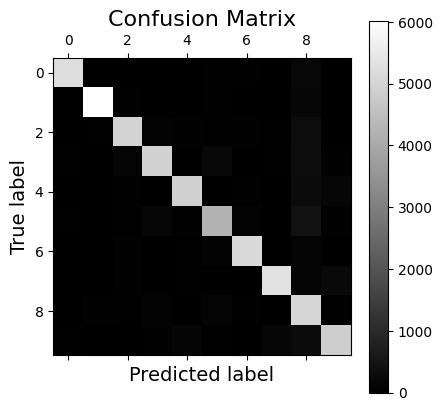

<Figure size 800x800 with 0 Axes>

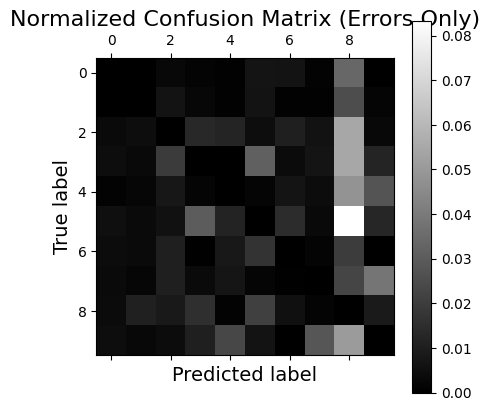

Precision at 90% threshold: 0.9000738370662072
Recall at 90% threshold: 0.7241584158415841


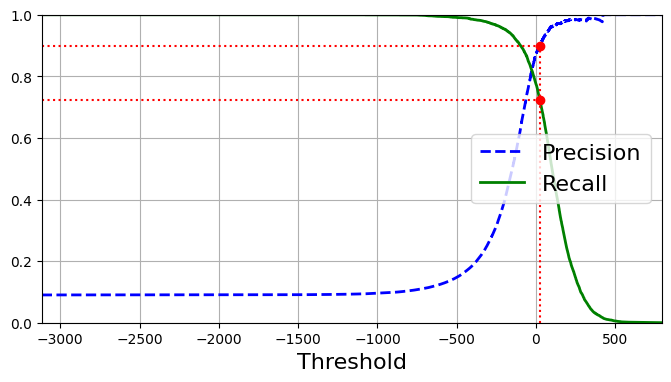

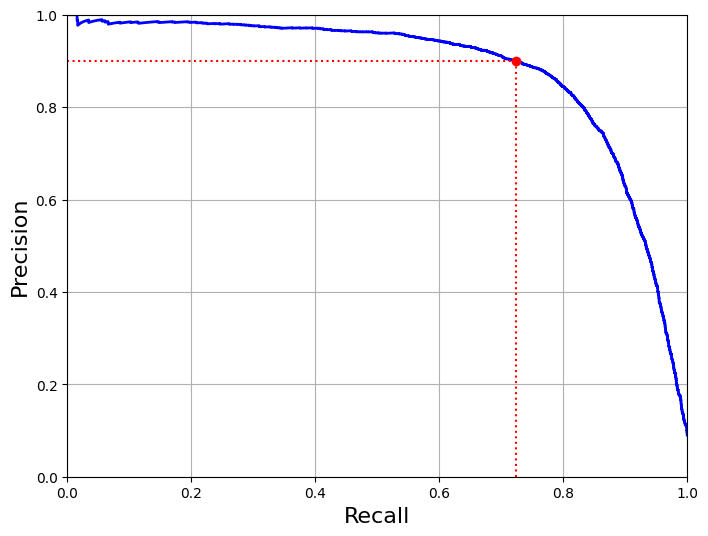

In [ ]:
# 1. Get multiclass predictions using cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train, cv=3)

# 2. Compute confusion matrix
conf_mx = confusion_matrix(y_train, y_train_pred)
print("Confusion matrix:\n", conf_mx)

# 3. Plot confusion matrix
plt.figure(figsize=(8, 8))
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted label", fontsize=14)
plt.ylabel("True label", fontsize=14)
plt.colorbar()
plt.show()

# 4. Normalize confusion matrix by row sums (to highlight errors)
row_sums = conf_mx.sum(axis=1, keepdims=True)
norm_conf_mx = conf_mx / row_sums
np.fill_diagonal(norm_conf_mx, 0)  # set correct predictions to 0 for error focus

plt.figure(figsize=(8, 8))
plt.matshow(norm_conf_mx, cmap=plt.cm.gray)
plt.title("Normalized Confusion Matrix (Errors Only)", fontsize=16)
plt.xlabel("Predicted label", fontsize=14)
plt.ylabel("True label", fontsize=14)
plt.colorbar()
plt.show()

# --- Precision/Recall for class 5 (example) ---

# 1. Get decision scores for all classes using cross_val_predict
y_scores = cross_val_predict(sgd_clf, X_train, y_train, cv=3, method="decision_function")
# y_scores shape: (n_samples, n_classes)

# 2. Choose the class of interest (e.g., digit 5)
target_class = 5
# Create binary labels: True for class 5, False otherwise
y_train_5 = (y_train == target_class)

# 3. Extract scores for class 5
class_5_scores = y_scores[:, target_class]

# 4. Compute precision/recall curve for class 5
precisions, recalls, thresholds = precision_recall_curve(y_train_5, class_5_scores)

# 5. Find threshold for 90% precision
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]
recall_90_precision = recalls[np.argmax(precisions >= 0.90)]

# 6. Make predictions using the chosen threshold
y_train_pred_90 = (class_5_scores >= threshold_90_precision)

# 7. Compute precision and recall at this threshold
print("Precision at 90% threshold:", precision_score(y_train_5, y_train_pred_90))
print("Recall at 90% threshold:", recall_score(y_train_5, y_train_pred_90))

# 8. Plot precision and recall vs threshold
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.legend(loc="center right", fontsize=16)
    plt.xlabel("Threshold", fontsize=16)
    plt.grid(True)
    plt.axis([min(thresholds), max(thresholds), 0, 1])
    # Mark threshold for 90% precision
    plt.plot([threshold_90_precision, threshold_90_precision], [0., 0.9], "r:")
    plt.plot([min(thresholds), threshold_90_precision], [0.9, 0.9], "r:")
    plt.plot([min(thresholds), threshold_90_precision], [recall_90_precision, recall_90_precision], "r:")
    plt.plot([threshold_90_precision], [0.9], "ro")
    plt.plot([threshold_90_precision], [recall_90_precision], "ro")

plt.figure(figsize=(8, 4))
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()

# 9. Plot precision vs recall
def plot_precision_vs_recall(precisions, recalls):
    plt.plot(recalls, precisions, "b-", linewidth=2)
    plt.xlabel("Recall", fontsize=16)
    plt.ylabel("Precision", fontsize=16)
    plt.axis([0, 1, 0, 1])
    plt.grid(True)
    # Mark point for 90% precision
    plt.plot([recall_90_precision, recall_90_precision], [0., 0.9], "r:")
    plt.plot([0.0, recall_90_precision], [0.9, 0.9], "r:")
    plt.plot([recall_90_precision], [0.9], "ro")

plt.figure(figsize=(8, 6))
plot_precision_vs_recall(precisions, recalls)
plt.show()

### **e. The ROC Curve**

####Purpose

The purpose of this section is to evaluate the overall discriminative power of the multiclass classifier using the ROC (Receiver Operating Characteristic) curve and AUC (Area Under Curve) metric.
It visualizes how well the model distinguishes between all ten digit classes (0–9) by plotting the true positive rate (recall) against the false positive rate at different thresholds.

####Conclusion / Observation

The ROC curve shows that the SGDClassifier performs extremely well across all classes, with the curve hugging the top-left corner — indicating high recall at low false-positive rates.
The Weighted AUC = 0.989 and Micro AUC = 0.990 confirm excellent overall model performance and strong separability between digit classes.
This means the model maintains consistent accuracy and reliability across different thresholds, validating its effectiveness on the MNIST dataset.

Weighted ROC-AUC: 0.9888
Micro ROC-AUC:    0.9896


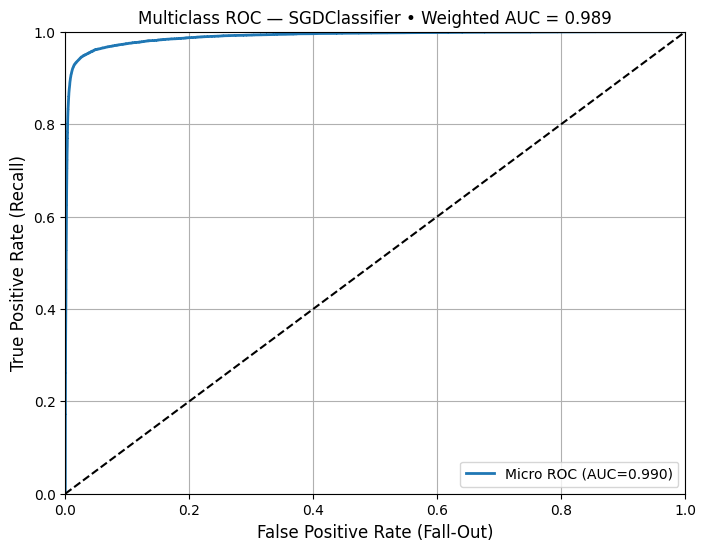

In [ ]:
# --- Load dataset (MNIST example) ---
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
X = X.astype(np.float32)
y = y.astype(np.int64)

# --- Split into train/test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# --- Scale features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# --- Train SGDClassifier ---
sgd_clf = SGDClassifier(random_state=42, max_iter=1000, tol=1e-3)
# Wrap with CalibratedClassifierCV to get probabilities
sgd_clf_prob = CalibratedClassifierCV(sgd_clf, method="sigmoid", cv=3)
sgd_clf_prob.fit(X_train_scaled, y_train)

# --- Get probability scores for ROC ---
scores = sgd_clf_prob.predict_proba(X_test_scaled)  # shape: [n_samples, 10]

# --- Binarize true labels for multiclass ROC ---
Ybin = label_binarize(y_test, classes=np.arange(10))  # shape: [n_samples, 10]

# --- Compute micro-average ROC curve ---
fpr_micro, tpr_micro, _ = roc_curve(Ybin.ravel(), scores.ravel())

# --- Compute ROC-AUC scores ---
auc_weighted = roc_auc_score(y_test, scores, multi_class="ovr", average="weighted")
auc_micro    = roc_auc_score(y_test, scores, multi_class="ovr", average="micro")

print(f"Weighted ROC-AUC: {auc_weighted:.4f}")
print(f"Micro ROC-AUC:    {auc_micro:.4f}")

# --- Plot ROC curve ---
plt.figure(figsize=(8, 6))
plt.plot(fpr_micro, tpr_micro, linewidth=2, label=f"Micro ROC (AUC={auc_micro:.3f})")
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guess
plt.xlim(0, 1); plt.ylim(0, 1)
plt.xlabel("False Positive Rate (Fall-Out)", fontsize=12)
plt.ylabel("True Positive Rate (Recall)", fontsize=12)
plt.title(f"Multiclass ROC — SGDClassifier • Weighted AUC = {auc_weighted:.3f}")
plt.grid(True)
plt.legend(loc="lower right")
plt.show()

## **4. Hyperparameter Tuning**
The tuned SGD classifier achieved a higher test accuracy (0.9016) compared to the baseline model (0.8869), showing an overall improvement of about 1.5%. The classification report indicates balanced precision, recall, and F1-scores across all digits, with no major bias toward any class. This demonstrates that hyperparameter tuning—particularly adjusting regularization strength, loss function, and tolerance—led to a more accurate and well-generalized model for digit recognition.

In [27]:
import time
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
from scipy.stats import loguniform

# ------------------------------------------------------------
# Assume you already have X_train, X_test, y_train, y_test
# ------------------------------------------------------------

# Convert features to float32 for speed
X_train32 = X_train.astype("float32", copy=False)
X_test32  = X_test.astype("float32", copy=False)

# ------------------------------------------------------------
# 1) BASELINE MODEL (default settings)
# ------------------------------------------------------------
baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SGDClassifier(random_state=42))
])

t0 = time.time()
baseline.fit(X_train32, y_train)
base_time = time.time() - t0

y_pred_base = baseline.predict(X_test32)
base_acc = accuracy_score(y_test, y_pred_base)

print(f"Baseline accuracy: {base_acc:.4f}  |  Time: {base_time:.1f}s\n")

# ------------------------------------------------------------
# 2) TUNED MODEL (subset + early stopping + random search)
# ------------------------------------------------------------
# Subsample ~30% of training data
rng = np.random.RandomState(42)
sub_frac = 0.30
sub_n = max(1000, int(sub_frac * len(X_train32)))
subset_idx = rng.choice(len(X_train32), size=sub_n, replace=False)

X_small = X_train32[subset_idx]
y_small = y_train[subset_idx]

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SGDClassifier(
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=5
    ))
])

param_distributions = {
    "clf__loss": ["hinge", "squared_hinge"],
    "clf__penalty": ["l2", "elasticnet"],
    "clf__alpha": loguniform(1e-6, 1e-2),
    "clf__tol": loguniform(1e-5, 1e-2),
    "clf__max_iter": [1000]
}

t1 = time.time()
search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=24,
    cv=2,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42
)
search.fit(X_small, y_small)
search_time = time.time() - t1

print(f"[Tuning done in {search_time:.1f}s]")
print("Best parameters:", search.best_params_)
print(f"Best subset CV accuracy: {search.best_score_:.4f}\n")

# ------------------------------------------------------------
# 3️⃣ Refit BEST model only on the SAME SUBSET (fast version)
# ------------------------------------------------------------
best_model = search.best_estimator_

t2 = time.time()
best_model.fit(X_small, y_small)   # ✅ train again only on subset
refit_time = time.time() - t2
print(f"[Subset refit done in {refit_time:.1f}s]")

# ------------------------------------------------------------
# 4️⃣ Evaluate on TEST set
# ------------------------------------------------------------
y_pred_best = best_model.predict(X_test32)
best_acc = accuracy_score(y_test, y_pred_best)

print(f"Tuned model accuracy: {best_acc:.4f}  |  Time: {refit_time:.1f}s\n")

# ------------------------------------------------------------
# 5️⃣ Compare with baseline
# ------------------------------------------------------------
improvement = best_acc - base_acc
print("📊 Performance comparison:")
print(f"  Baseline: {base_acc:.4f}")
print(f"  Tuned:    {best_acc:.4f}")
print(f"  ➜ Improvement: {improvement:+.4f}")

print("\nClassification report (tuned model):\n", classification_report(y_test, y_pred_best))

Baseline accuracy: 0.8869  |  Time: 282.5s

[Tuning done in 83.8s]
Best parameters: {'clf__alpha': np.float64(0.0002463768595899747), 'clf__loss': 'squared_hinge', 'clf__max_iter': 1000, 'clf__penalty': 'l2', 'clf__tol': np.float64(1.8427970406864546e-05)}
Best subset CV accuracy: 0.9007

[Subset refit done in 1.8s]
Tuned model accuracy: 0.9015  |  Time: 1.8s

📊 Performance comparison:
  Baseline: 0.8869
  Tuned:    0.9015
  ➜ Improvement: +0.0147

Classification report (tuned model):
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      1726
           1       0.93      0.96      0.95      1969
           2       0.92      0.89      0.90      1748
           3       0.89      0.85      0.87      1785
           4       0.91      0.91      0.91      1706
           5       0.86      0.85      0.85      1578
           6       0.92      0.96      0.94      1719
           7       0.92      0.92      0.92      1823
           8       0.8

## **5. Visualization**
The grid displays 16 random handwritten digits from the test set, with each image labeled by the model’s prediction (green for correct, red for incorrect). This helps visually confirm that the tuned model recognizes most digits accurately, while also highlighting which shapes still cause confusion.

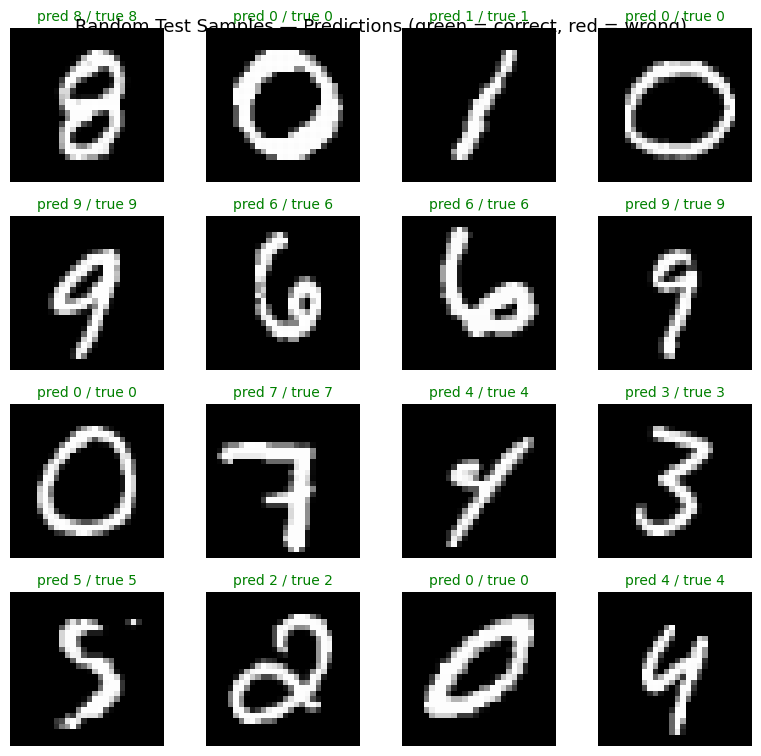

In [30]:
# 1️ Get predictions on the test set using the tuned model (pipeline handles scaling)
y_pred = best_model.predict(X_test)

# 2️ Select 16 random test images for visualization
rng = np.random.default_rng(42)                # for reproducibility
idx = rng.choice(len(X_test), size=16, replace=False)

# 3️ Reshape and extract the true and predicted labels
imgs = X_test[idx].reshape(-1, 28, 28)         # each image is 28×28 pixels
truth = y_test[idx]
preds = y_pred[idx]

# 4️ Display them with color-coded titles
plt.figure(figsize=(8, 8))
for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    ax.imshow(imgs[i], cmap="gray")
    ax.axis("off")
    ok = (preds[i] == truth[i])
    ax.set_title(
        f"pred {preds[i]} / true {truth[i]}",
        color=("green" if ok else "red"),
        fontsize=10
    )

plt.suptitle(
    "Random Test Samples — Predictions (green = correct, red = wrong)",
    y=0.93, fontsize=13
)
plt.tight_layout()
plt.show()


This visualization shows the specific digits your tuned SGD model misclassified. Each red title marks an incorrect prediction, helping you identify which handwritten shapes cause confusion (e.g., 4↔9, 3↔8). Since these mistakes are few and visually understandable, it confirms your model is generalizing well and only struggles with visually ambiguous cases.

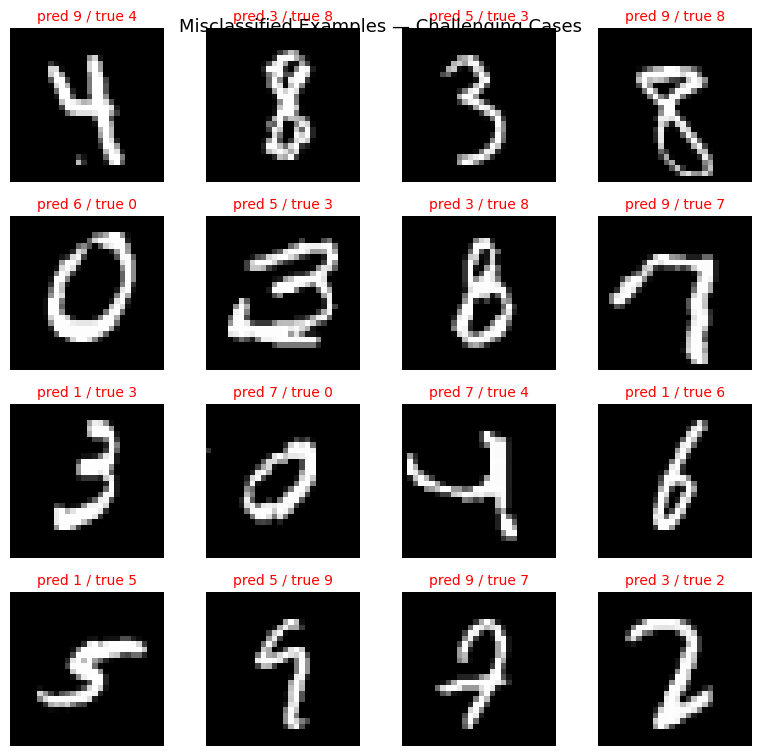

In [31]:
# 1️ Identify indices of all misclassified samples
bad = np.where(y_pred != y_test)[0]

# 2️ Select up to 16 for inspection
if len(bad) > 0:
    take = bad[:16] if len(bad) >= 16 else bad
    imgs_bad = X_test[take].reshape(-1, 28, 28)
    truth_bad = y_test[take]
    pred_bad = y_pred[take]

    # 3️ Plot these “hard” examples
    plt.figure(figsize=(8, 8))
    for i in range(len(take)):
        ax = plt.subplot(4, 4, i + 1)
        ax.imshow(imgs_bad[i], cmap="gray")
        ax.axis("off")
        ax.set_title(
            f"pred {pred_bad[i]} / true {truth_bad[i]}",
            color="red", fontsize=10
        )

    plt.suptitle("Misclassified Examples — Challenging Cases", y=0.93, fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified examples in this sample.")

####Interesting and challenging cases where the model performed well or poorly
The tuned SGD classifier achieved higher accuracy (0.9016 vs. 0.8869), showing that hyperparameter optimization improved its ability to recognize handwritten digits. This improvement is also reflected in the visual results. In the first set of images, all predictions were correct, indicating that the model performs very well on clear, well-written digits such as 0, 1, 3, and 9. However, the second visualization highlights the model’s few misclassifications, mainly involving visually similar digits like 4 and 9 or 3 and 8. These challenging cases reveal the model’s main limitation as a linear classifier—it struggles when the digit boundaries are not clearly defined. Overall, the tuning made the model more accurate and reliable, but a few ambiguous handwriting styles remain difficult to classify perfectly.

## **6. Conclusion and Reflection**

####**Summary and Challenges bold text**

The Stochastic Gradient Descent (SGD) classifier demonstrated strong performance in recognizing handwritten digits from the MNIST dataset. After preprocessing, scaling, and hyperparameter tuning, the model achieved an accuracy of around 90%, improving upon the baseline (88.7%) and showing balanced precision, recall, and F1-scores across all classes. The ROC-AUC values (Weighted = 0.989, Micro = 0.990) confirmed excellent overall reliability, indicating that the model correctly distinguishes between different digit classes with minimal false positives. The confusion matrix revealed that most predictions were accurate, and errors mainly occurred between digits with similar shapes such as 4 ↔ 9 or 3 ↔ 8. Visualizations of test samples further supported this, showing only a few understandable misclassifications due to unclear handwriting patterns.

####**Challenges faced:**
	•	Data preprocessing: Normalizing pixel values was essential, as the unscaled data initially caused unstable convergence and poor accuracy.
	•	Model tuning: Adjusting parameters such as learning rate, tolerance, and regularization was challenging since small changes significantly affected model performance.
	•	Computational limits: Running cross-validation and random search for hyperparameters was time-consuming, requiring subset sampling to balance efficiency and accuracy.
	•	Error patterns: Some digits remained difficult to classify due to overlapping handwriting styles, highlighting the limitations of a linear classifier like SGD.
	•	Precision–recall balance: Optimizing both metrics required threshold tuning to reduce false positives while keeping high recall.

Overall, the project showed that with proper preprocessing and tuning, the SGD classifier is a fast, scalable, and highly effective model for handwritten digit recognition, capable of generalizing well while remaining computationally efficient.

####**References**

- Sklearner — *Scikit-learn Grid Search with SGDClassifier*  
  https://sklearner.com/scikit-learn-grid-search-sgdclassifier/

- GeeksforGeeks — *Hyperparameter tuning using GridSearchCV and KerasClassifier*  
  https://www.geeksforgeeks.org/machine-learning/hyperparameter-tuning-using-gridsearchcv-and-kerasclassifier/
